# Urban 3D Point Cloud Segmentation

Segment a local 3D point cloud into height clusters and inspect class composition.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by PDAL and PyVista point-cloud processing examples with offline data.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import trimesh
import pyvista as pv
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
points = pd.read_csv(DATA / 'point_cloud.csv')
print({'points': len(points), 'pyvista': pv.__version__})
display(points.head())


{'points': 900, 'pyvista': '0.48.4'}


,x,y,z,class
0,3.067,67.850,3.863,ground
1,19.394,74.496,4.132,ground
2,29.273,72.823,4.849,ground
3,65.077,70.769,17.389,canopy
4,91.549,5.525,5.153,ground


In [2]:
xyz = points[['x', 'y', 'z']].to_numpy()
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(xyz)
points['cluster'] = km.labels_
points['height_above_min'] = points['z'] - points.groupby('cluster')['z'].transform('min')
cloud = trimesh.points.PointCloud(xyz)
print({'bounds': cloud.bounds.round(2).tolist(), 'clusters': points['cluster'].nunique()})
display(points.groupby(['cluster', 'class']).size().unstack(fill_value=0))


{'bounds': [[0.0, 0.02, 1.83], [99.94, 99.79, 21.74]], 'clusters': 3}


class,canopy,ground
cluster,,
0,110,169
1,111,255
2,94,161


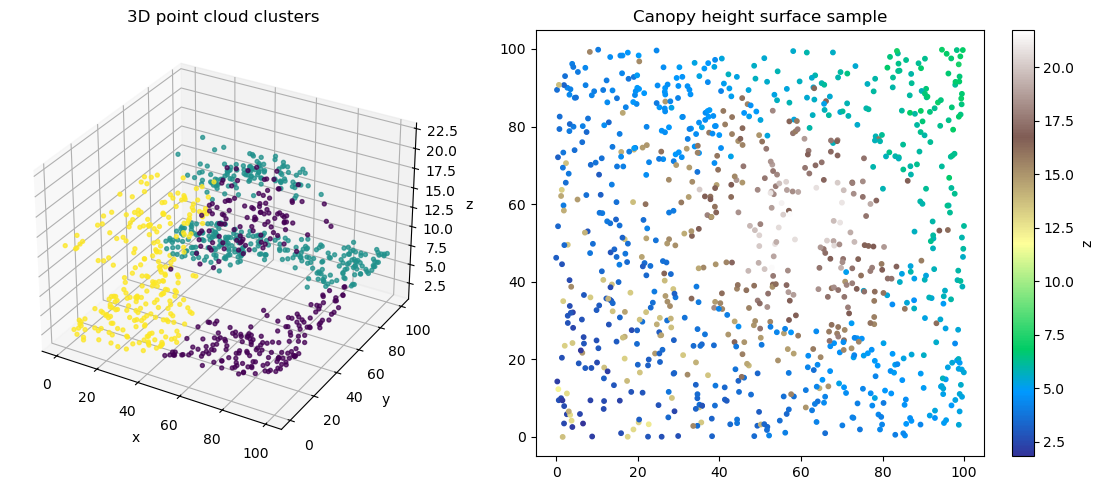

In [3]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(points.x, points.y, points.z, c=points.cluster, cmap='viridis', s=8, alpha=0.75)
ax.set_title('3D point cloud clusters')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax2 = fig.add_subplot(1, 2, 2)
sc = ax2.scatter(points.x, points.y, c=points.z, cmap='terrain', s=10)
ax2.set_title('Canopy height surface sample')
fig.colorbar(sc, ax=ax2, label='z')
fig.tight_layout()
fig.savefig(OUT / 'pointcloud_clusters.png', dpi=160)
plt.show()


In [4]:
summary = points.groupby('cluster').agg(mean_z=('z', 'mean'), max_z=('z', 'max'), points=('z', 'size')).round(2)
display(summary)


,mean_z,max_z,points
cluster,,,
0,9.70,21.74,279
1,8.84,21.61,366
2,7.39,19.49,255
